# Tacoma EV Adoption Analysis

This notebook explores electric vehicle adoption trends in Tacoma, Washington.
The goal is to analyze EV population data and prepare datasets for visualization
in a Tableau dashboard.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import seaborn as sns

print("Libraries loaded successfully")

In [ ]:

ev_data = pd.read_csv("../data/Electric_Vehicle_Population_Data_03_09_2026.csv")

len(ev_data)

In [ ]:
ev_data.info()

In [ ]:
ev_data.describe()

In [ ]:
ev_data["ev_type"].value_counts()

## Distribution of Electric Vehicle Types

This chart shows the distribution of Battery Electric Vehicles (BEV) and
Plug-in Hybrid Electric Vehicles (PHEV) in the dataset.

The dataset shows that BEVs dominate the EV registrations.

In [79]:
tacoma_ev = ev_data[ev_data["City"] == "Tacoma"]
tacoma_ev.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
74975,5YJ3E1EA3J,Pierce,Tacoma,WA,98422.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,27.0,272128783,POINT (-122.37683 47.28642),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305394e+10
75452,KM8KRDAF0P,Pierce,Tacoma,WA,98406.0,2023,HYUNDAI,IONIQ 5,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,27.0,237801406,POINT (-122.52082 47.26887),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305306e+10
76004,5YJ3E1EA6L,Pierce,Tacoma,WA,98444.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266.0,29.0,259678359,POINT (-122.43827 47.154),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305307e+10
76081,5YJ3E1EAXP,Pierce,Tacoma,WA,98422.0,2023,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,27.0,260024460,POINT (-122.37683 47.28642),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305394e+10
76564,2C4RC1H78L,Pierce,Tacoma,WA,98418.0,2020,CHRYSLER,PACIFICA,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,32.0,27.0,278872744,POINT (-122.44629 47.22283),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305306e+10


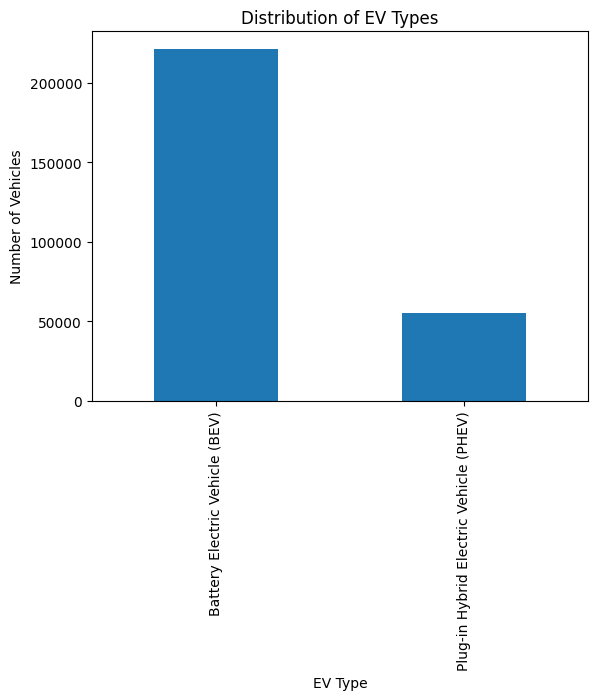

In [80]:
ev_data["Electric Vehicle Type"].value_counts().plot(kind="bar")

plt.title("Distribution of EV Types")
plt.xlabel("EV Type")
plt.ylabel("Number of Vehicles")

plt.show()

In [81]:
tacoma_ev = ev_data[ev_data["City"] == "Tacoma"]
top_makes = tacoma_ev["Make"].value_counts().head(10) 
print(top_makes)

Make
TESLA         2020
CHEVROLET      543
KIA            486
NISSAN         485
FORD           477
TOYOTA         295
HYUNDAI        235
BMW            199
VOLKSWAGEN     194
JEEP           131
Name: count, dtype: int64


*Distribution of Top 10 EV Makes in Tacoma*

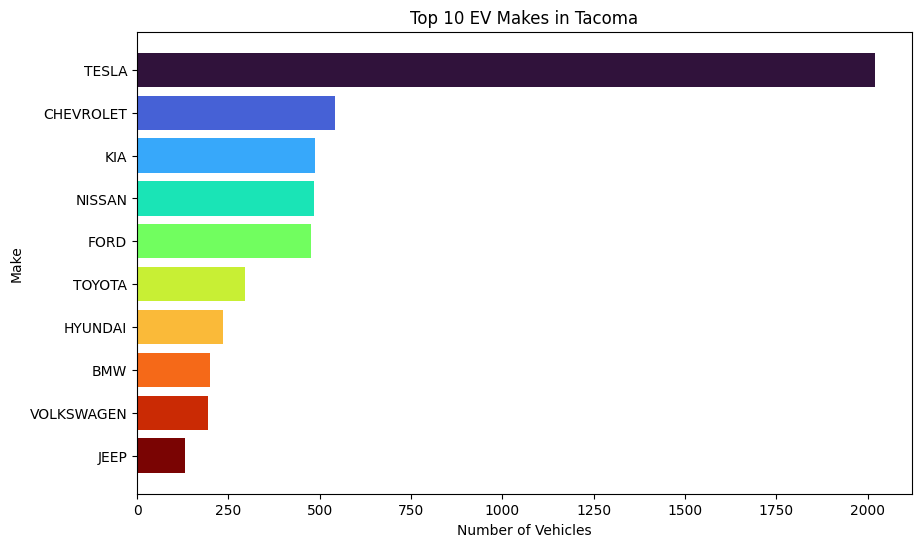

In [82]:
makes = top_makes.index
counts = top_makes.values

colors = cm.turbo(np.linspace(0, 1, len(makes)))

plt.figure(figsize=(10,6))
plt.barh(makes, counts, color=colors)
plt.xlabel("Number of Vehicles")
plt.ylabel("Make")
plt.title("Top 10 EV Makes in Tacoma")
plt.gca().invert_yaxis() 
plt.show()

In [83]:
ev_type_counts = tacoma_ev["Electric Vehicle Type"].value_counts()
print(ev_type_counts)

Electric Vehicle Type
Battery Electric Vehicle (BEV)            4609
Plug-in Hybrid Electric Vehicle (PHEV)    1392
Name: count, dtype: int64


*Distribution of EV Types in Tacoma*

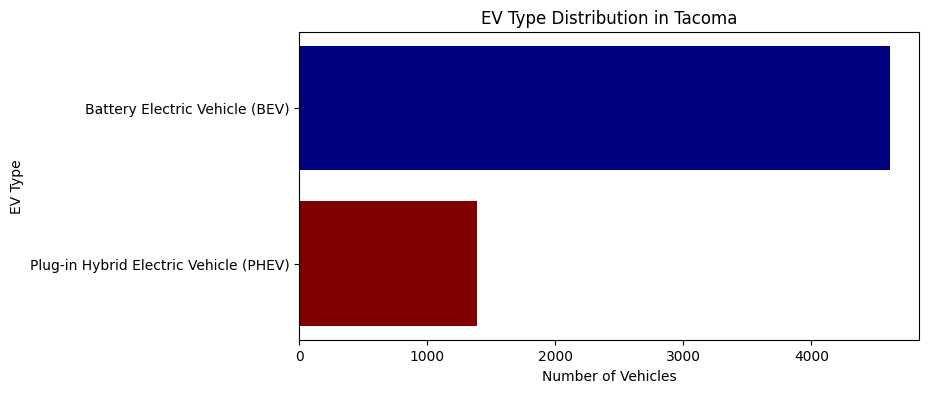

In [84]:
types = ev_type_counts.index
counts = ev_type_counts.values

colors = cm.jet(np.linspace(0, 1, len(types)))

plt.figure(figsize=(8,4))
plt.barh(types, counts, color=colors)
plt.xlabel("Number of Vehicles")
plt.ylabel("EV Type")
plt.title("EV Type Distribution in Tacoma")
plt.gca().invert_yaxis()  # largest on top
plt.show()